2025년 자율이동체 시스템 강의 자료 입니다.

# 데이터 셋 준비

## 내려받기

아래에 접속합니다.

https://www.cvlibs.net/datasets/kitti/eval_odometry.php

1. odometry ground truth poses (4 MB)

2. odometry data set (grayscale, 22 GB)

그리고 LMS에 업로드 한 별도의 calibration 파일을 내려받습니다. 

3. data_odometry_calib.zip

## 간단한 소개

작업 폴더로 옮겨 형태부터 살펴봅니다.

데이터는 4541개의 행과 12개의 열로 구성되어 있습니다.

• 4541은 이 시퀀스에서의 이미지 프레임 수를 의미하고,

• 12는 3×4 변환 행렬을 평탄화(flatten)하여 얻은 값입니다.

이 변환 행렬은 왼쪽 스테레오 카메라의 좌표계를 글로벌 좌표계 기준으로 나타낸 것입니다.

여기서 글로벌 좌표계는 카메라가 처음 위치한 프레임의 좌표계를 기준으로 정의됩니다.

하나의 3×4 변환 행렬은 다음과 같은 형태로 구성됩니다:

• 왼쪽 3×3 부분은 회전 행렬 (R)

• 오른쪽 3×1 부분은 평행 이동 벡터 (t)

즉, 전체 행렬은 R|t 형태입니다.

In [2]:
import pandas as pd

poses = pd.read_csv('./dataset/poses/00.txt', delimiter=' ', header=None)
print('Data sahpe:', poses.shape)
poses.head()

Data sahpe: (4541, 12)


,0,1,2,3,4,5,6,7,8,9,10,11
0,1.000000,9.043680e-12,2.326809e-11,5.551115e-17,9.043683e-12,1.000000,2.392370e-10,3.330669e-16,2.326810e-11,2.392370e-10,1.000000,-4.440892e-16
1,0.999998,5.272628e-04,-2.066935e-03,-4.690294e-02,-5.296506e-04,0.999999,-1.154865e-03,-2.839928e-02,2.066324e-03,1.155958e-03,0.999997,8.586941e-01
2,0.999991,1.048972e-03,-4.131348e-03,-9.374345e-02,-1.058514e-03,0.999997,-2.308104e-03,-5.676064e-02,4.128913e-03,2.312456e-03,0.999989,1.716275e+00
3,0.999980,1.566466e-03,-6.198571e-03,-1.406429e-01,-1.587952e-03,0.999993,-3.462706e-03,-8.515762e-02,6.193102e-03,3.472479e-03,0.999975,2.574964e+00
4,0.999964,2.078471e-03,-8.263498e-03,-1.874858e-01,-2.116664e-03,0.999987,-4.615826e-03,-1.135202e-01,8.253797e-03,4.633149e-03,0.999955,3.432648e+00


이를 확인하기 위해 첫 번째 포즈를 살펴보면, 회전 성분은 단위 행렬(Identity matrix)이고, 평행 이동 벡터는 모든 축에 대해 0으로 되어 있는 것을 볼 수 있습니다.

이를 이해하기 위해 OpenCV 사이트를 참고해서 진행을 합시다. 설명은 강의 영상을 참고하세요.

https://docs.opencv.org/4.x/d9/d0c/group__calib3d.html

In [43]:
import numpy as np
print('First position:')
first_pose = np.array(poses.iloc[0]).reshape((3,4)).round(2)
print(first_pose)
print('The second position:')
second_pose = np.array(poses.iloc[1]).reshape((3,4)).round(2)
print(second_pose)
print('The third position:')
third_pose = np.array(poses.iloc[2]).reshape((3,4)).round(2)
print(third_pose)

First position:
[[ 1.  0.  0.  0.]
 [ 0.  1.  0.  0.]
 [ 0.  0.  1. -0.]]
The second position:
[[ 1.    0.   -0.   -0.05]
 [-0.    1.   -0.   -0.03]
 [ 0.    0.    1.    0.86]]
The third position:
[[ 1.    0.   -0.   -0.09]
 [-0.    1.   -0.   -0.06]
 [ 0.    0.    1.    1.72]]


OpenCV 설명 중 Pinhole camera model 그림을 보면 카메라 좌표계(Fc)가 표시된 모습을 볼 수 있습니다.

강의에서 이 이미지를 여러 번 참조하니 익숙해 지세요.

지금은 우선 카메라 좌표계의 축 방향을 잘 확인해두시고, 차량의 움직임이 추적되는 글로벌 좌표계는 시퀀스에서 카메라가 처음 위치한 시점의 좌표계를 기준으로 정의된다는 점을 이해하기 바랍니다.

OpenCV 내용을 간단히 검증(sanity check) 해 봅시다.

우선, 모든 정답 위치(ground truth, gt) 변환 행렬을 numpy 배열 형태로 저장하여 쉽게 접근할 수 있도록 합니다:

In [11]:
gt = np.zeros((len(poses), 3, 4))
for i in range(len(poses)):
    gt[i] = np.array(poses.iloc[i]).reshape((3, 4))

이제 두 번째 프레임의 변환 행렬, 그러니까 gt[1]을 가져와서, 해당 프레임에서 카메라의 원점(자기 자신의 좌표계에서의 원점: 0, 0, 0, 1)과 내적을 계산하면, 카메라가 글로벌 좌표계 (즉, 시퀀스에서 첫 번째 프레임의 좌표계)를 기준으로 어디에 위치해 있는지 알 수 있습니다.

여기서 우리는 동차 좌표(homogeneous coordinates)를 사용하고 있는데, 이는 3D 벡터의 끝에 1을 추가한 것입니다.

이렇게 하면 회전 성분과 평행 이동 성분을 한 번의 행렬 곱으로 계산할 수 있어 매우 편리합니다.

이 기법은 이후에도 여러 번 유용하게 사용될 것입니다.

gt[0]은 (0,0,0)임을 확인할 수 있습니다. 약간의 값이 들어가 있지만 노이즈입니다. 

In [14]:
print(gt[0].dot(np.array([0,0,0,1])))
print(gt[1].dot(np.array([0,0,0,1])))
print(gt[2].dot(np.array([0,0,0,1])))

[ 5.551115e-17  3.330669e-16 -4.440892e-16]
[-0.04690294 -0.02839928  0.8586941 ]
[-0.09374345 -0.05676064  1.716275  ]


영상 초반에 차량이 앞으로 움직이고 있었다는 사실을 알고 있고, 그 결과 벡터에서 Z 값(전방 방향)이 양수로 나타난 것을 볼 수 있습니다.

즉, 두 번째 프레임에서 카메라는 첫 번째 프레임에 비해 약 0.85미터 앞쪽에 위치해 있었던 것입니다.

또한, 이후 확인하게 되겠지만 카메라는 초당 약 10프레임(FPS)으로 작동하기 때문에,

이는 약 8.5 m/s, 즉 시속 약 30.6km/h이기 때문에 물리적으로 적절한 속도입니다. 

이제 gt 포즈 배열이 준비되었으므로, 차량이 시퀀스를 따라 이동한 실제 궤적(trajectory)을 살펴볼 수 있습니다.

여기에서는 회전(rotation)에 대해 크게 신경 쓰지 않아도 됩니다.

그 이유는, 회전의 효과가 시간에 따라 변화하는 카메라 원점의 위치에 포함되어 있기 때문입니다.

이는 각 변환 행렬의 네 번째 열(column)로 표현되어 있습니다.

궤적을 살펴보면 우차량의 궤적이 출발점과 도착점이 동일하며, 몇 개의 코너를 돌고, 약간 경사진 언덕 위를 지나갔다는 것을 확인할 수 있습니다.

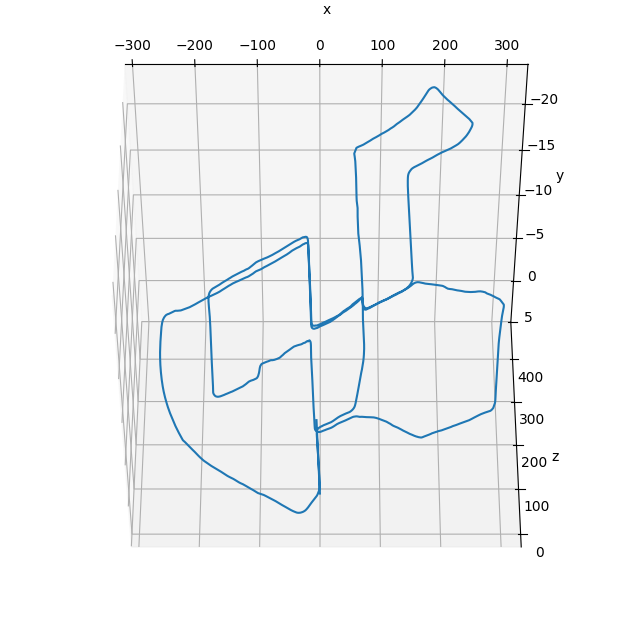

In [20]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection='3d')
ax.plot(gt[:, :, 3][:, 0], gt[:, :, 3][:, 1], gt[:, :, 3][:, 2])
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.view_init(elev=-40, azim=270)

## 이미지 확인

이제 첫 번째 이미지를 간단히 확인해 보겠습니다.

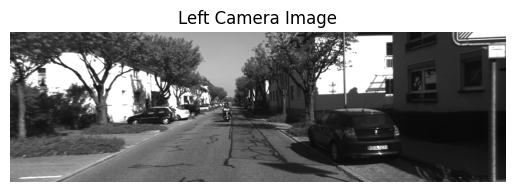

In [30]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread('./dataset/sequences/00/image_0/000000.png')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # OpenCV는 이미지를 BGR로 읽기 때문에 RGB로 변환해 줍니다. 

plt.imshow(img_rgb)
plt.title("Left Camera Image")
plt.axis('off') 
plt.show()

# 데이터 살펴보기

이제 데이터를 살펴 봅시다. 

먼저 폴더 내 파일 이름 목록을 확인합니다.

In [34]:
import os 
left_image_files = os.listdir('./dataset/sequences/00/image_0')
print(left_image_files[:5])

['001927.png', '001099.png', '000387.png', '003856.png', '002590.png']


시퀀스 내 이미지 개수를 세어 보고 gt pose 개수(4541개)와 일치하는지 봅시다.

In [35]:
print(len(left_image_files))
print(len(poses))

4541
4541


확인 결과, 이미지 개수와 gt pose 개수가 완벽히 일치함을 알 수 있습니다.

첫 번째 gt pose는 (0, 0, 0)이므로, 첫 번째 카메라 프레임을 기준으로 이후 프레임에서의 카메라의 움직임을 추적하고 있습니다. 

Time step 도 확인할 수 있습니다. 

In [36]:
times = pd.read_csv('./dataset/sequences/00/times.txt', delimiter=' ', header=None)
times.head()

,0
0,0.000000
1,0.103736
2,0.207338
3,0.311075
4,0.414692


노이즈를 감안하면 약 0.1초 간격임을 확인할 수 있습니다(10 fps).

우리는 총 4개의 카메라에 대한 3×4 투영 행렬(projection matrix)과, LIDAR의 변환 행렬(Tr) 값이 있습니다. 

Tr은 라이다 데이터로 Kitty Dataset 홈페이지에서 내려받는 경우 이 파일이 없습니다. LMS의 파일을 이용하세요. 이번 강의에서 사용하는 데이터는 아닙니다.

In [41]:
calib = pd.read_csv('./dataset/sequences/00/calib.txt', delimiter=' ', header=None, index_col=0)
print(calib)

             1         2           3           4         5           6   \
0                                                                         
P0:  718.856000  0.000000  607.192800    0.000000  0.000000  718.856000   
P1:  718.856000  0.000000  607.192800 -386.144800  0.000000  718.856000   
P2:  718.856000  0.000000  607.192800   45.382250  0.000000  718.856000   
P3:  718.856000  0.000000  607.192800 -337.287700  0.000000  718.856000   
Tr:    0.000428 -0.999967   -0.008084   -0.011985 -0.007211    0.008081   

             7         8         9         10        11        12  
0                                                                  
P0:  185.215700  0.000000  0.000000  0.000000  1.000000  0.000000  
P1:  185.215700  0.000000  0.000000  0.000000  1.000000  0.000000  
P2:  185.215700 -0.113089  0.000000  0.000000  1.000000  0.003780  
P3:  185.215700  2.369057  0.000000  0.000000  1.000000  0.004915  
Tr:   -0.999941 -0.054040  0.999974  0.000486 -0.007207 -0.292197 

## 카메라 행렬의 이해

P0는 왼쪽 회색 카메라의 투영 행렬(projection matrix)입니다. 

In [44]:
P0 = np.array(calib.loc['P0:']).reshape((3,4))
print(P0)

[[718.856    0.     607.1928   0.    ]
 [  0.     718.856  185.2157   0.    ]
 [  0.       0.       1.       0.    ]]


투영 행렬은 카메라의 초점 거리(focal length)와 광학 중심(optical center)과 같은 내부 파라미터에 대한 정보를 포함하고 있습니다.

이 행렬을 이용해 각 카메라의 좌표계를 글로벌 좌표계, 즉 P1의 경우 왼쪽 흑백 카메라의 좌표계와 연결해 주는 변환을 할 수 있습니다.

투영 행렬은 글로벌 좌표계에 있는 3차원 좌표를 카메라의 이미지 평면 위에 투영하는 역할을 하며, 그 수식과 그림은 셋업 페이지와 함께 OpenCV를 참조하여 이해할 수 있습니다. 

간단히 왼쪽 카메라와 오른쪽 카메라의 좌표 차이가 X축을 기준으로 0.54미터인데, 이를 확인해 봅시다.

In [47]:
P1 = np.array(calib.loc['P1:']).reshape((3,4))
k1, r1, t1, _, _, _, _ = cv2.decomposeProjectionMatrix(P1)
t1 = t1 / t1[3]
print('Left and right greyscale camera:')
print(t1.round(4))

Left and right greyscale camera:
[[0.5372]
 [0.    ]
 [0.    ]
 [1.    ]]


카메라의 내적인 요인, 즉 초점 거리(focal length)와 광학 중심(optical center) 등의 파라미터를 포함하고 있는 행렬을 내부 행렬이라고 하며, K로 표기합니다.

외부 요인은 외부 행렬 [R|t]이며 앞서 차량의 ground truth pose에서 본 것과 같은 형태로 3×3 회전 행렬과 3×1 이동 벡터가 수평으로 결합된 구조를 갖습니다.

투영 행렬은 내부 행렬과 외부 행렬의 곱으로 구성합니다.

강의 영상에서의 수식을 보면 방정식의 왼쪽에 λ가 곱해지는데, 여기서 λ는 스케일(scale)이라고 부릅니다.

이는 카메라로부터 해당 점까지의 깊이(depth), 그러니까 3D 점에 변환 행렬 R|t를 적용하여 카메라 좌표계로 변환한 후의 Z축 값이 λ에 해당합니다.

보정(calibration) 파일에 포함된 투영 행렬들은 스테레오 장비(stereo rig) 기준에서 각 카메라에 대해 정렬(rectification)된 이후의 투영 행렬입니다.

일반적으로 카메라의 투영 행렬은 글로벌 좌표계에 있는 3차원 점을 해당 카메라의 이미지 평면상의 픽셀 좌표로 투영하는 역할을 합니다.

그러나 여기서의 투영 행렬, 그러니까 정렬된 투영 행렬(rectified projection matrix)은 이와는 정반대로 동작하며, 모든 카메라의 좌표계에 있는 점들을 하나의 공통된 이미지 평면, 즉 왼쪽 카메라의 이미지 평면에 매핑하도록 설계되어 있습니다.

단순히 생각하면 방향이 반대라는 의미입니다. 

즉, 이 행렬들은 각 카메라 좌표계의 3D 점들을 왼쪽 카메라의 이미지 평면으로 투영하고 있습니다.

일반적인 투영 행렬 개념으로 표현한다면, P0부터 P3까지는 각각의 카메라에 대해 정의되어 있지만, 실질적으로는 모두 왼쪽 흑백 카메라를 기준으로 투영하고 있는 네 개의 서로 다른 투영 행렬이다. 각 행렬은 자신이 속한 카메라의 좌표계를 일종의 “글로벌 좌표계”로 보고 그 기준에서 왼쪽 카메라의 이미지 평면으로 투영하는 방식이라고 이해하면 됩니다.

셋업을 다시 보면 두 쌍의 스테레오 카메라가 존재하며, 하나는 흑백(grayscale) 카메라 세트이고 다른 하나는 RGB 카메라 세트이다. 이 중 흑백 카메라의 기준선(baseline), 즉 왼쪽과 오른쪽 카메라 사이의 거리는 왼쪽 카메라의 X축 기준으로 0.54미터입니다.

만약 제공된 투영 행렬들이 일반적인 per-camera 투영 행렬이었다면, 우리는 외부 행렬(extrinsic matrix)이 글로벌 좌표계에 있는 점을 해당 카메라의 좌표계로 변환해 준다고 생각할 수 있습니다. 

예를 들어, 글로벌 좌표계의 원점(즉, 왼쪽 흑백 카메라의 원점)을 오른쪽 흑백 카메라의 좌표계로 변환하면, X좌표가 -0.54가 되어야 한다. 이는 왼쪽 카메라의 원점이 오른쪽 카메라의 원점보다 X축 방향으로 0.54미터 왼쪽에 있기 때문입니다.

이번 경우에는, 이 [R|t] 행렬을 사용해 글로벌 좌표계의 원점 (0, 0, 0, 1)을 오른쪽 카메라 좌표계로 변환해 봅시다.

도식에 따르면, 그 결과는 X = -0.54가 되어야 합니다.

OpenCV의 분해 함수는 이동 벡터 t를 동차 좌표(homogeneous coordinate) 형태로 반환하므로, 이를 R과 수평 결합(hstack)할 때는 네 번째 값은 제거해 줍니다.

In [48]:
Rt = np.hstack([r1, t1[:3]])

origin = np.array([0, 0, 0, 1])
Rt.dot(origin).round(4).reshape(-1,1)

array([[0.5372],
       [0.    ],
       [0.    ]])

변환 결과의 X값이 +0.54로 나타났는데, 이는 카메라 좌표계 기준으로 오른쪽 방향으로 0.54m 떨어져 있다는 의미입니다.

이는 이 투영 행렬이 실제로는 오른쪽 카메라에 대한 것이 아니라, 왼쪽 카메라의 이미지 평면을 기준으로 오른쪽 카메라의 좌표계 원점을 투영하고 있다는 말이겠지요?

이는 해당 투영 행렬이 스테레오 장비(stereo rig)를 위한 정렬(rectified)된 투영 행렬이기 때문이며, 이 행렬의 목적은 여러 카메라의 좌표계에 있는 3D 점들을 모두 하나의 공통된 이미지 평면(왼쪽 카메라의 이미지 평면)에 투영하는 데 있습니다.

즉, 여러 카메라의 좌표계 → 하나의 이미지 평면 방향으로 작동하고, 일반적인 projection matrix와는 반대 방향으로 이해하면 됩니다.

따라서 각 정렬된 projection matrix는,해당 센서(카메라)의 좌표계에 있는 3D 점들 (X, Y, Z, 1)을 왼쪽 흑백 카메라의 이미지 평면 상의 픽셀 좌표 (u, v, 1)로 변환하게 됩니다.

나아가 앞서 계산에서 얻은 결과가 이동 벡터 t와 동일하다는 점을 살펴 봅시다.

“글로벌” 좌표계의 원점이 특정 카메라 좌표계에서 어디에 위치해 있는지를 알고 싶다면, 별도로 변환 연산을 수행할 필요 없이 t 벡터만 확인하면 됩니다.

이 경우, 분해한 정렬된 투영 행렬에서 나온 외부 행렬은, 오른쪽 카메라의 좌표계 원점(즉, 이 좌표계를 글로벌로 본다면)이 왼쪽 카메라 기준으로 오른쪽 방향으로 0.54m에 위치해 있음을 나타내며, 이는 셋업에서 확인한 값과 정확히 일치합니다.

## 이해 확인하기

이제 이해했는지 확인을 해 봅시다. 

이 정렬된 projection matrix를 오른쪽 흑백 카메라를 위한 일반적인 projection matrix로 변환합니다. 

변환 절차를 정리하면 다음과 같습니다.
1. 이미 분해해 놓은 Rt 행렬을 사용
2. 이를 동차 변환 행렬(homogeneous transformation matrix)로 확장
3. 이 행렬을 역변환(inverse)
4. 다시 intrinsic 행렬과 곱하여 새로운 projection matrix 구성

우리는 이미 [R|t]를 수평 결합한 상태이므로, 이제 다음 단계로 4x4 동차 행렬로 확장하고,
이를 역행렬로 변환한 뒤, 원래의 내부 행렬과 결합하여
일반적인 의미에서의 오른쪽 카메라 projection matrix를 완성할 수 있다.

이후 이를 이용해, 왼쪽 카메라의 좌표계 원점을 변환해 보면 X = -0.54가 나오는지 확인해 보면 됩니다.

In [49]:
T_homogeneous = np.vstack([Rt, np.array([0, 0, 0, 1])])
T_hom_inv = np.linalg.inv(T_homogeneous)
print('Homogeneous transformation matrix:')
print(T_homogeneous.round(4))
print('Inverted homogeneous transformation matrix:')
print(T_hom_inv.round(4))

Homogeneous transformation matrix:
[[1.     0.     0.     0.5372]
 [0.     1.     0.     0.    ]
 [0.     0.     1.     0.    ]
 [0.     0.     0.     1.    ]]
Inverted homogeneous transformation matrix:
[[ 1.      0.      0.     -0.5372]
 [ 0.      1.      0.     -0.    ]
 [ 0.      0.      1.     -0.    ]
 [ 0.      0.      0.      1.    ]]


우리의 이동 벡터 t가 실제로 -0.54로 바뀐 것을 확인할 수 있습니다. 

### 첫번째 과제

첫번째 과제는 두 RGB 카메라의 투영 행렬을 구해 보는 것입니다. 정렬된 행렬이 아닌 두 RGB 카메라의 투영 행렬을 구해 보세요.

## 투영 행렬(projection matrix)의 이해

주어진 좌표계의 3D 점을 카메라의 이미지 평면으로 투영하는 식을 돌아보며, 여기서 등장하는 λ 값에 대해 좀 더 자세히 알아봅시다.

λ는 단일 점에 대해 투영을 수행할 경우 하나의 값, 여러 점을 처리할 경우 각 점에 대해 하나씩 포함된 벡터로 나타납니다. 

이 값은 변환 행렬 [R|t]를 3D 점에 적용한 후, 그 결과의 Z값, 즉 해당 점이 카메라 좌표계에서 갖는 깊이(depth)입니다.

3차원 점들을 2차원 이미지 평면에 투영하기 위해 우리는 각 점을 그 깊이로 나누게 되며, 이로 인해 모든 점은 결과적으로 Z값이 1이 되는 평면, 즉 카메라 원점에서 Z축 방향으로 1만큼 떨어진 가상의 평면에 투영됩니다.

여기서 중요한 점은, λ로 나누는 연산은 수식의 어디서 수행하든 결과에 영향을 미치지 않습니다. 예를 들어:
1. (X, Y, Z, 1) 자체를 λ로 나눈 후 행렬 곱을 할 수도 있고
2. [R|t] \cdot (X, Y, Z, 1) 한 후 λ로 나눈 다음 K와 곱할 수도 있고
3. 모든 행렬 곱을 마친 후 마지막에 결과를 λ로 나눌 수도 있습니다.

이 세 가지 방법 모두 최종적으로 동일한 결과를 제공합니다.

물론, 첫 번째 방법은 사실상 불가능합니다. 

왜냐하면 λ는 [R|t] \cdot (X, Y, Z, 1) 연산의 결과로 얻은 카메라 좌표계에서의 Z값이기 때문입니다. 

따라서 λ를 얻기도 전에 나눌 수는 없습니다.

하지만 개념을 이해하기 위해 파이썬 코드로 각 방식의 연산을 수행해보고 동일한 결과가 나오는지 확인해 봅시다.

먼저 왼쪽 카메라가 시퀀스에서 14번째 포즈에 있을 때의 좌표계 기준으로 측정된 어떤 3D 점을 하나 선택하고, 이 점을 왼쪽 카메라가 처음 위치한 좌표계의 이미지 평면에 투영해 봅시다.

예로 14번째 포즈에 해당하는 ground truth 변환 행렬을 사용할게요. 먼저, 해당 프레임에서 측정된 점의 좌표를 봅시다.

In [51]:
some_point = np.array([1, 2, 3, 1]).reshape(-1,1)
print(some_point)

[[1]
 [2]
 [3]
 [1]]


## 깊이(depth) 구하기

이제 이 점을 카메라 좌표계로 변환한 뒤, Z값을 추출하여 해당 점이 카메라로부터 얼마나 떨어져 있는지(depth)를 구해 봅니다.

변환은 조금 전에 구성한 [R|t] 행렬 또는 ground truth 행렬을 통해 변환할 수 있어요.

원래 점의 위치(original point), 카메라 좌표계로 변환된 점의 위치(Transformed point), 그리고 해당 점이 카메라로부터 얼마나 깊이에 위치하는지(Z 값, depth from camera)를 확인할 수 있습니다.

In [53]:
transformed_point = gt[14].dot(some_point)
depth_from_cam = transformed_point[2]

print('Original point:\n', some_point)
print('Transformed point:\n', transformed_point.round(4))
print('Depth from camera:\n', depth_from_cam.round(4))

Original point:
 [[1]
 [2]
 [3]
 [1]]
Transformed point:
 [[ 0.2706]
 [ 1.5461]
 [15.0755]]
Depth from camera:
 [15.0755]


이제 이 3D 점을 이미지 평면에 투영해봅니다. 두 방법을 생각해 볼 수 있어요.

첫 번째는, 내부 행렬 K**를 먼저 곱한 다음 깊이(depth)로 나누는 방식입니다.

이렇게 하면,

• 먼저 미터 단위의 3D 좌표가 픽셀 × 미터가 되고,

• 그 후 깊이로 나누어 픽셀 단위의 좌표가 됩니다.

두 번째는 먼저 깊이로 나눈 후에 내부 행렬 K를 곱하는 방식입니다.

이 경우,

• 먼저 미터를 깊이로 나누어 무차원 단위(unitless)로 만든 뒤,

• 이를 픽셀 단위로 변환합니다.

In [ ]:
pixel_coordinates1 = k1.dot(transformed_point) / depth_from_cam

pixel_coordinates2 = k1.dot(transformed_point / depth_from_cam)

print('Pixel Coordinates 1st way:', pixel_coordinates1.T)
print('Pixel Coordinates 2nd way:', pixel_coordinates2.T)

Pixel Coordinates 1st way: [[620.09802465 258.93763336   1.        ]]
Pixel Coordinates 2nd way: [[620.09802465 258.93763336   1.        ]]


두 방법의 결과가 동일한 것을 알 수 있어요.

추가로 픽셀 좌표를 정규화(normalize)해야 합니다.

이는 내부 행렬 K의 역행렬을 곱하여 수행합니다.

픽셀 좌표는 단위가 픽셀이므로, 역행렬을 곱함으로써 무차원 좌표계로 변환할 수 있습니다.

이 정규화된 좌표는 일반적으로 카메라 행렬을 추정하는 문제에서 사용되는데, 동차 좌표가 픽셀 위치를 의미하는 매우 큰 값(예: 수백~수천)을 가지고 있고, 세 번째 값은 1로 작기 때문에, 수치적으로 ill-conditioned(수치적으로 불안정한) 행렬을 만들 수 있기 때문입니다.

정규화 좌표는 이런 문제를 피하고 계산의 안정성을 높여줍니다.

In [55]:
normalized_coordinates = np.linalg.inv(k1).dot(pixel_coordinates1)
print('Normalized Coordinates:', normalized_coordinates.T)

Normalized Coordinates: [[0.01795245 0.10255452 1.        ]]


이제 예시로 정규화된 좌표에 깊이를 곱하여 원래 3D 좌표를 복원해 보겠습니다.

이는 투영된 2D 좌표와 깊이 정보만 있다면 3D 점의 위치를 재구성할 수 있음을 보여줍니다.

우선 다시 카메라 좌표계에서의 3D 위치로 돌아갑니다.

In [57]:
restored_3D = normalized_coordinates.T * depth_from_cam
print(restored_3D.round(4))

[[ 0.2706  1.5461 15.0755]]


이 점을 원래의 좌표계(14번째 포즈의 카메라 기준이 아닌)로 다시 변환하려면,
1. 기존 변환 행렬을 4×4 동차 변환 행렬(homogeneous transformation matrix)로 만들고
2. 이를 역변환(invert)한 후,
3. 변환하려는 점에도 1을 추가해 동차 좌표로 변환한 뒤
4. 행렬 곱을 수행합니다.

In [ ]:
T_homogeneous = np.vstack([gt[14], np.array([0, 0, 0, 1])])
T_hom_inv = np.linalg.inv(T_homogeneous)
restored_3D_hom = np.append(restored_3D, 1)
T_hom_inv.dot(restored_3D_hom)

정리하면 다음 과정을 완료한 셈입니다.
1. 3D 점을 한 좌표계에서 정의하고
2. 그것을 다른 좌표계의 카메라 이미지에 투영하고
3. 깊이를 이용해 다시 3D로 복원한 뒤
4. 동차 변환 행렬의 역행렬을 사용해 원래 좌표계로 되돌리는 연산을 수행했습니다.

이후 차량이 글로벌 좌표계 상에서 어디에 위치해 있는지를 계산할 때 위와 같은 연산을 사용하면 됩니다. 